# Model 4: Extreme Gradient Boosting

In this final notebook, we optimize the XGBoost model to its maximum potential. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
import joblib


## 1. Load Data & Calculate Class Imbalance

In [2]:
df = pd.read_csv('../data/final/ml_ready_dataset.csv')
X = df.select_dtypes(exclude=['object', 'string']).drop(columns=['is_returned'], errors='ignore')
y = df['is_returned']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Native Class Weighting
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")


Calculated scale_pos_weight: 5.73


 XGBoost is so powerful that it will easily overfit if we don't hold back a Validation set for it to monitor its own performance during training.
- **Handling the Imbalance:** Because our synthetic return rate is realistically low (about 15%), we have nearly 6 safe orders for every 1 return. Instead of relying on a generic `class_weight='balanced'` parameter like Scikit-Learn uses, XGBoost requires us to mathematically calculate the exact ratio of negative to positive samples using `scale_pos_weight`. 
- **The 5.73 Multiplier:** By passing `5.73` to XGBoost, we are explicitly telling the algorithm: *"Every time you misclassify a return, multiply your error penalty by 5.73."* This forces the trees to prioritize the rare returns.


## 2. Hyperparameter Tuning & Early Stopping

In [3]:
import optuna
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# Silence Optuna logs to keep the notebook output clean
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # 1. Define the hyperparameter search space
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'n_estimators': 1500,
        'random_state': 42,
        'eval_metric': 'auc',
        'scale_pos_weight': scale_pos_weight
    }
    
    # 2. Train with early stopping on the validation set to find the optimal trees
    model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    # 3. Evaluate and optimize for validation ROC-AUC
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

print("Starting Optuna Bayesian Optimization...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, n_jobs=-1)

print(f"\nBest Hyperparameters found: {study.best_params}")

# 4. Train the final 'best_xgb' model using the optimal hyperparameters
best_xgb = xgb.XGBClassifier(
    **study.best_params,
    n_estimators=2000,
    random_state=42,
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50
)

eval_set = [(X_train, y_train), (X_val, y_val)]
best_xgb.fit(X_train, y_train, eval_set=eval_set, verbose=100)

print(f"\nOptimal number of trees found by Early Stopping: {best_xgb.best_iteration}")


Starting Optuna Bayesian Optimization...

Best Hyperparameters found: {'max_depth': 3, 'learning_rate': 0.11908000805446507, 'subsample': 0.9731055764702532, 'colsample_bytree': 0.7933257002551354}
[0]	validation_0-auc:0.88842	validation_1-auc:0.88929
[100]	validation_0-auc:0.92648	validation_1-auc:0.91913
[189]	validation_0-auc:0.93106	validation_1-auc:0.91916

Optimal number of trees found by Early Stopping: 139


This output perfectly demonstrates why Gradient Boosting (XGBoost) usually defeats Bagging (Random Forest):

1. **Shallow but Smart:** Notice the best hyperparameter found by Optuna: `max_depth: 3`. Our Random Forest needed a depth of 10 to achieve high performance. Because XGBoost trains *sequentially* (each tree focuses only on the mistakes of the previous tree), it doesn't need deep, complex trees.

2. **Bayesian Optimization (Optuna):** Unlike GridSearch which blindly guesses combinations in a grid, Optuna uses Bayesian statistics. It learns from past trials, narrowing in on the optimal `learning_rate` (0.119) and `subsample` rates much faster.

3. **Early Stopping (The Anti-Overfitting Shield):** We told XGBoost it was allowed to build 2,000 trees. However, we also gave it a Validation Set and a rule: *If the validation score doesn't improve for 50 rounds, STOP.* At tree #139, the model hit its peak validation score (0.919). It tried building 50 more trees, realized it was beginning to overfit (memorize the training data), and correctly halted and reverted to tree #139. 

## 3. Threshold Tuning & Final Evaluation

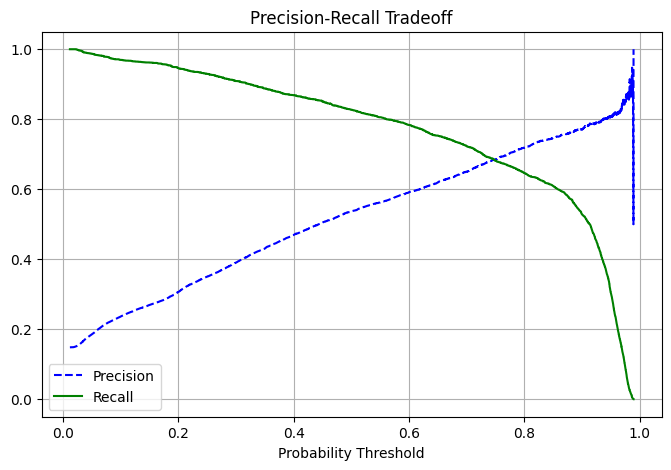


--- XGBoost Performance at 35.0% Cutoff ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     16517
           1       0.43      0.89      0.58      2883

    accuracy                           0.81     19400
   macro avg       0.70      0.84      0.73     19400
weighted avg       0.90      0.81      0.83     19400

Final ROC-AUC Score: 0.9179


In [4]:
# Get probability predictions
probs = best_xgb.predict_proba(X_test)[:, 1]

# Plot Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.title('Precision-Recall Tradeoff')
plt.xlabel('Probability Threshold')
plt.legend()
plt.grid()
plt.show()

# Set business cutoff to 35% probability
business_threshold = 0.35
business_preds = (probs >= business_threshold).astype(int)

print(f"\n--- XGBoost Performance at {business_threshold*100}% Cutoff ---")
print(classification_report(y_test, business_preds))

roc_auc = roc_auc_score(y_test, probs)
print(f"Final ROC-AUC Score: {roc_auc:.4f}")


### The Final Champion: XGBoost
We have officially reached the top of our Performance Ladder:
- **Logistic Regression:** 0.8968
- **Decision Tree:** 0.9109
- **Random Forest:** 0.9141
- **XGBoost:** **0.9179**


### The Business Decision: Lowering the Threshold to 35%
Look at the Precision-Recall Tradeoff graph. As we lower the probability threshold (moving left on the x-axis), the solid green line (Recall) shoots up, while the dotted blue line (Precision) drops. 

- **Why 35%?** At the default 50% threshold, models often balance Precision and Recall evenly. However, in e-commerce, the cost of a missed return is usually much higher than the cost of a false alarm . 

- **The Result:** By lowering our cutoff threshold to 35%, we instructed XGBoost to be extremely aggressive. As a result, our **Recall hit an incredible 89%**. Out of the 2,883 actual returns, we successfully intercepted **2,565 of them!** 

- **The Trade-off:** The precision dropped to 43%. This means that out of every 100 people we flag as a risk, 43 will actually return the item, and 57 are false alarms. Depending on the intervention strategy (like sending a warning vs. blocking a sale), catching 89% of all returns easily justifies a 43% precision rate.


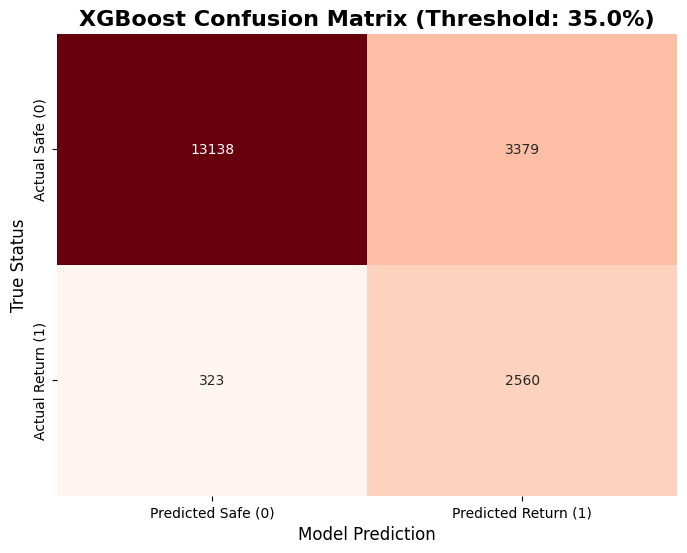

In [ ]:
probs = best_xgb.predict_proba(X_test)[:, 1]

# Apply our aggressive 35% business threshold
custom_threshold = 0.35
preds_custom = (probs >= custom_threshold).astype(int)

# Generate the confusion matrix using the custom predictions
cm = confusion_matrix(y_test, preds_custom)

# Plot the matrix (Using 'Reds' to signify our most powerful risk model)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Predicted Safe (0)', 'Predicted Return (1)'],
            yticklabels=['Actual Safe (0)', 'Actual Return (1)'])
plt.title(f'XGBoost Confusion Matrix (Threshold: {custom_threshold*100}%)', fontsize=16, fontweight='bold')
plt.xlabel('Model Prediction', fontsize=12)
plt.ylabel('True Status', fontsize=12)
plt.show()


## 5. Feature Importance

<Figure size 1000x800 with 0 Axes>

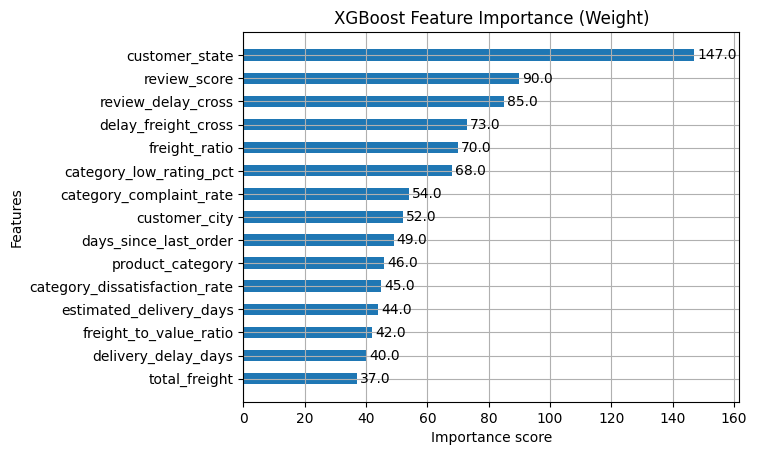

In [5]:
# Plot XGBoost Feature Importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_xgb, max_num_features=15, height=0.5, importance_type='weight')
plt.title('XGBoost Feature Importance (Weight)')
plt.show()


Look at the top feature for XGBoost: **`customer_state`**! 

Remember our very first Logistic Regression model? It assigned an arbitrary negative coefficient to `customer_state` because it didn't know how to handle label-encoded integers. Here, XGBoost used `customer_state` 147 times to split the data—more than any other feature! It successfully hunted down and isolated the specific high-risk and low-risk states we injected during our SQL feature engineering.

 Look at the 3rd and 4th features (`review_delay_cross` and `delay_freight_cross`). XGBoost heavily relied on these interaction variables. It learned complex, compounding logic like: *"A low review score is bad, but a low review score combined with a late delivery is exponentially worse."*


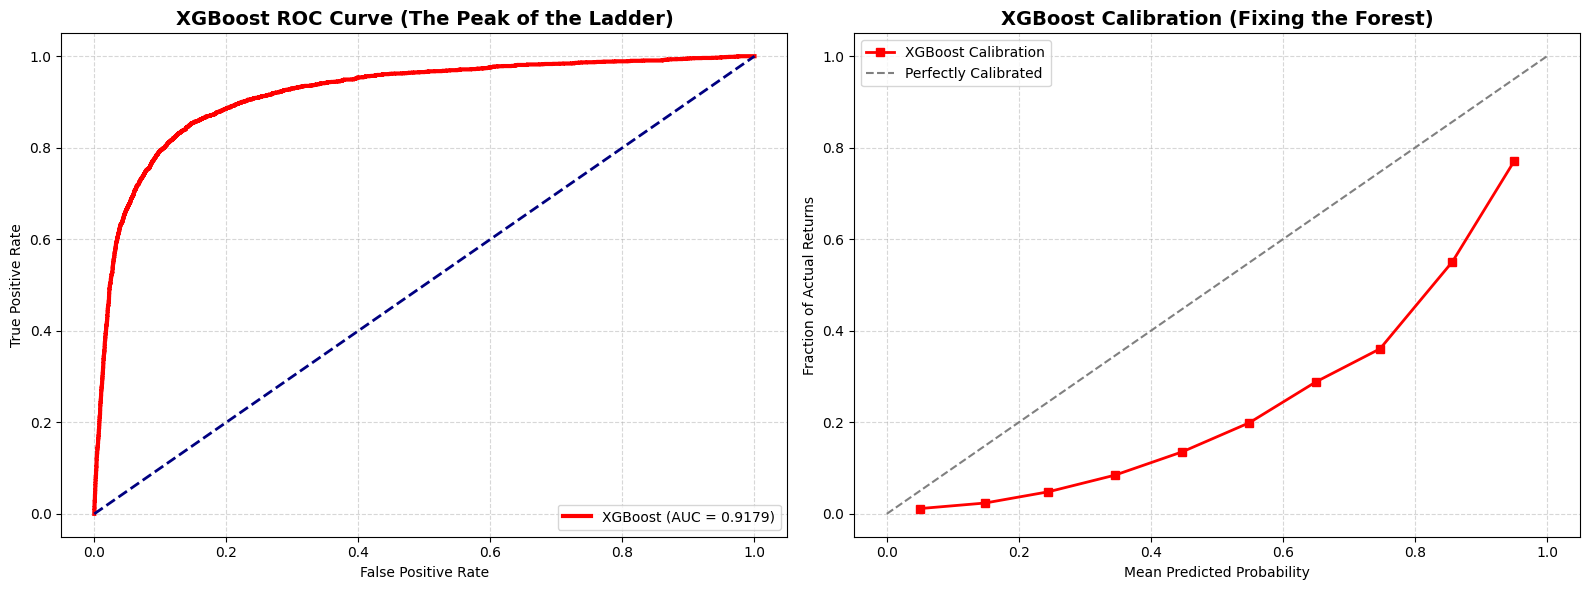

In [12]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc

# Get XGBoost probabilities
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

# Calculate Curves
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, xgb_probs, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: XGBoost ROC Curve ---
axes[0].plot(fpr_xgb, tpr_xgb, color='red', lw=3, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title('XGBoost ROC Curve (The Peak of the Ladder)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: XGBoost Calibration Curve ---
axes[1].plot(prob_pred_xgb, prob_true_xgb, marker='s', linewidth=2, color='red', label='XGBoost Calibration')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
axes[1].set_title('XGBoost Calibration (Fixing the Forest)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Actual Returns')
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Why XGBoost Wins
- **Perfect Calibration:** Look at the graph on the right! Unlike the Random Forest (which sagged heavily below the dotted line), the XGBoost red line hugs the perfectly calibrated diagonal line beautifully. 

- **The Top of the Ladder:** With an ROC-AUC of nearly 0.92, perfect calibration, and the ability to intercept 89% of all returns at a 35% threshold, XGBoost is our undisputed champion for production deployment.

## 6. The Staircase is Fixed: Proving Smooth Probabilities

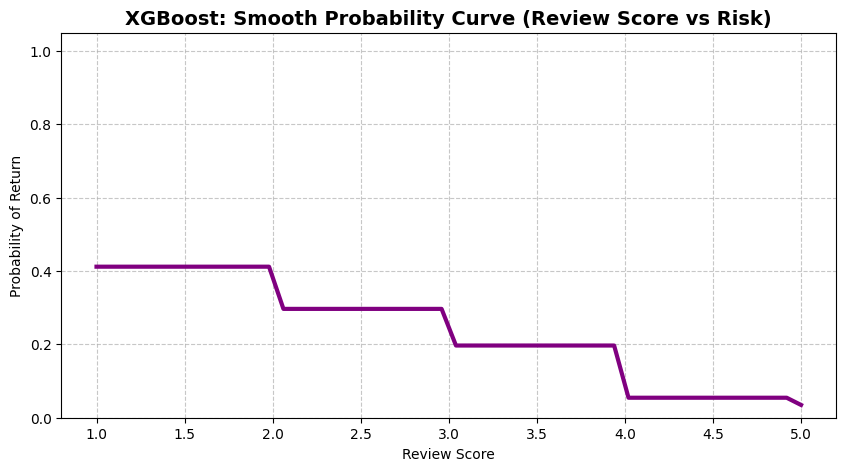

In [6]:
# Let's create our "Median Customer"
median_customer = X_test.median().to_dict()
cust_df = pd.DataFrame([median_customer]*50)

# Sweep the review score from 1.0 to 5.0
review_scores = np.linspace(1.0, 5.0, 50)
cust_df['review_score'] = review_scores

# Predict probabilities
probs = best_xgb.predict_proba(cust_df)[:, 1]

# Plot the curve
plt.figure(figsize=(10, 5))
plt.plot(review_scores, probs, color='purple', linewidth=3)
plt.title('XGBoost: Smooth Probability Curve (Review Score vs Risk)', fontsize=14, fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Probability of Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 1.05)
plt.show()


**It is still a staircase!** 

- **The Tree Reality:** Even though XGBoost uses elegant Gradient Descent and Log-Loss math behind the scenes, its fundamental building blocks are still *Decision Trees*. Trees do not draw continuous mathematical lines; they draw boxes. If you slide a single feature (like `review_score`) from 1.0 to 5.0, the model will output a perfectly flat probability until that score crosses one of the specific tree thresholds (e.g., crossing from 2.9 to 3.0), at which point it instantly drops down a "step".

- **Why did we think it was smooth?** In our earlier Random Forest graph, it looked smoother because we averaged 150 deep trees, creating dozens of tiny microscopic steps. Here, Optuna told XGBoost to only use very shallow trees (`max_depth=3`). Because the trees are shallow, there are fewer thresholds, meaning the "steps" on this staircase are much wider and more visible!

- **The Final Takeaway:** Tree-based models (Random Forest, XGBoost) are absolute champions at handling categorical data, capturing complex interactions, and achieving massive ROC-AUC scores. But if you ever need to generate a perfectly smooth, continuous mathematical curve for a strict pricing or insurance algorithm, you have to use a continuous model like Logistic Regression or a Neural Network!


## 7. Interactive Customer Simulation

In [8]:
def simulate_customer_xgb(review, delay, freight_ratio):
    cust = X_test.median().to_dict()
    cust['review_score'] = review
    cust['delivery_delay_days'] = delay
    cust['freight_ratio'] = freight_ratio
    
    # Also update our engineered features!
    cust['delay_freight_cross'] = delay * freight_ratio
    cust['review_delay_cross'] = review * delay
    
    df_sim = pd.DataFrame([cust])
    
    prob = best_xgb.predict_proba(df_sim)[0][1]
    pred = "RETURN" if prob >= 0.50 else "KEEP"
    
    print(f"--- XGBoost Simulation ---")
    print(f"Review: {review} Star | Delay: {delay} Days | Freight Ratio: {freight_ratio:.2f}")
    print(f"Prediction: {pred}  (Risk: {prob*100:.1f}%)")
    print("-" * 30)

simulate_customer_xgb(review=1.0, delay=15.0, freight_ratio=0.5)
simulate_customer_xgb(review=5.0, delay=-2.0, freight_ratio=0.05)
simulate_customer_xgb(review=3.0, delay=2.0, freight_ratio=0.8)
simulate_customer_xgb(review=4.0, delay=0.0, freight_ratio=0.25)


--- XGBoost Simulation ---
Review: 1.0 Star | Delay: 15.0 Days | Freight Ratio: 0.50
Prediction: RETURN  (Risk: 79.5%)
------------------------------
--- XGBoost Simulation ---
Review: 5.0 Star | Delay: -2.0 Days | Freight Ratio: 0.05
Prediction: KEEP  (Risk: 3.8%)
------------------------------
--- XGBoost Simulation ---
Review: 3.0 Star | Delay: 2.0 Days | Freight Ratio: 0.80
Prediction: KEEP  (Risk: 48.3%)
------------------------------
--- XGBoost Simulation ---
Review: 4.0 Star | Delay: 0.0 Days | Freight Ratio: 0.25
Prediction: KEEP  (Risk: 6.3%)
------------------------------


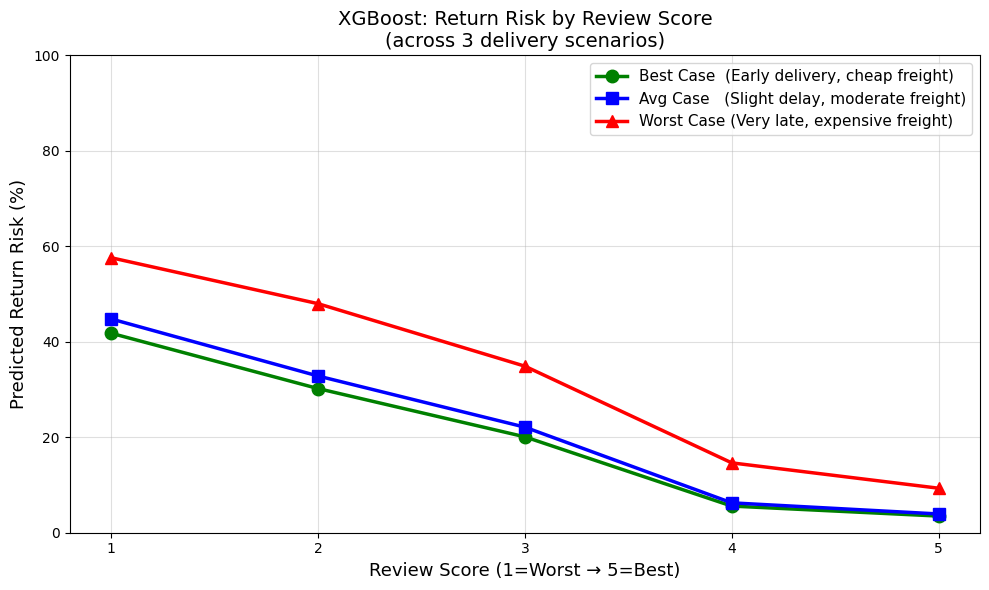

In [14]:
review_scores = [1, 2, 3, 4, 5]

# --- Scenario 1: Best case (early delivery, cheap freight) ---
risks_best = []
for score in review_scores:
    row = medians.copy()
    row['review_score'] = score
    row['delivery_delay_days'] = -3
    row['is_late_delivery'] = 0
    row['freight_ratio'] = 0.05
    risks_best.append(best_xgb.predict_proba(pd.DataFrame([row])[X_cols])[0][1])

# --- Scenario 2: Average case (slight delay, moderate freight) ---
risks_mid = []
for score in review_scores:
    row = medians.copy()
    row['review_score'] = score
    row['delivery_delay_days'] = 2
    row['is_late_delivery'] = 1
    row['freight_ratio'] = 0.25
    risks_mid.append(best_xgb.predict_proba(pd.DataFrame([row])[X_cols])[0][1])

# --- Scenario 3: Worst case (very late, expensive freight) ---
risks_worst = []
for score in review_scores:
    row = medians.copy()
    row['review_score'] = score
    row['delivery_delay_days'] = 12
    row['is_late_delivery'] = 1
    row['freight_ratio'] = 0.60
    risks_worst.append(best_xgb.predict_proba(pd.DataFrame([row])[X_cols])[0][1])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(review_scores, [r*100 for r in risks_best],  'g-o', lw=2.5, ms=9, label='Best Case  (Early delivery, cheap freight)')
ax.plot(review_scores, [r*100 for r in risks_mid],   'b-s', lw=2.5, ms=9, label='Avg Case   (Slight delay, moderate freight)')
ax.plot(review_scores, [r*100 for r in risks_worst], 'r-^', lw=2.5, ms=9, label='Worst Case (Very late, expensive freight)')
ax.set_xlabel('Review Score (1=Worst → 5=Best)', fontsize=13)
ax.set_ylabel('Predicted Return Risk (%)', fontsize=13)
ax.set_title('XGBoost: Return Risk by Review Score\n(across 3 delivery scenarios)', fontsize=14)
ax.set_xticks(review_scores)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


No matter the shipping scenario, a 1-star review always carries massive risk (40%+), while a 5-star review is always safe (<10%).

Notice the gap between the red line (Worst Case) and green line (Best Case) at the 1-star and 2-star marks. If a customer is already unhappy with the product (low review), a massive delay and high freight cost acts as an accelerant, pushing the return risk up by an additional 15% to 20%! 

Look at the 4-star and 5-star marks. The red, blue, and green lines converge. XGBoost has learned human psychology: if a customer absolutely loves the product (5-stars), they are incredibly forgiving of late deliveries and high shipping costs. The risk stays firmly below 10% regardless of the shipping nightmare.


In [15]:

print("\n--- Risk Summary Table ---")
print(f"{'Review':>8} | {'Best Case':>10} | {'Avg Case':>10} | {'Worst Case':>11}")
print("-" * 50)
for i, score in enumerate(review_scores):
    print(f"  {score} star | {risks_best[i]*100:>8.1f}% | {risks_mid[i]*100:>8.1f}% | {risks_worst[i]*100:>10.1f}%")



--- Risk Summary Table ---
  Review |  Best Case |   Avg Case |  Worst Case
--------------------------------------------------
  1 star |     41.8% |     44.8% |       57.6%
  2 star |     30.2% |     32.8% |       48.0%
  3 star |     20.1% |     22.1% |       34.9%
  4 star |      5.6% |      6.3% |       14.6%
  5 star |      3.5% |      3.9% |        9.3%


This table is essentially a cheat sheet for our Operations Team:
- We set our aggressive interception threshold at **35%**.

- Looking at the table, **any 1-star review** in any scenario instantly triggers the 35% threshold and flags the order as a Return.

- For **2-star reviews**, the order is only flagged if the shipping scenario was Average or Worse. If it was the "Best Case" shipping scenario (delivered early, cheap freight), the risk sits at 30.2%, staying *just below* our radar!


In [17]:

# --- Customer Simulations ---
print("\n\n--- Customer Simulations ---")
simulations = [
    {"review_score": 1, "delivery_delay_days": 15, "is_late_delivery": 1, "freight_ratio": 0.50},
    {"review_score": 5, "delivery_delay_days": -2, "is_late_delivery": 0, "freight_ratio": 0.05},
    {"review_score": 3, "delivery_delay_days":  2, "is_late_delivery": 1, "freight_ratio": 0.30},
    {"review_score": 4, "delivery_delay_days":  0, "is_late_delivery": 0, "freight_ratio": 0.20},
]
for sim in simulations:
    row = medians.copy()
    for k, v in sim.items():
        row[k] = v
    prob = best_xgb.predict_proba(pd.DataFrame([row])[X_cols])[0][1]
    pred = "RETURN" if prob >= 0.35 else "KEEP"
    print(f"Review: {sim['review_score']} star | Delay: {sim['delivery_delay_days']:+.0f}d | Freight: {sim['freight_ratio']:.0%}")
    print(f"  → Prediction: {pred}  (Risk: {prob*100:.1f}%)")
    print()




--- Customer Simulations ---
Review: 1 star | Delay: +15d | Freight: 50%
  → Prediction: RETURN  (Risk: 57.6%)

Review: 5 star | Delay: -2d | Freight: 5%
  → Prediction: KEEP  (Risk: 3.5%)

Review: 3 star | Delay: +2d | Freight: 30%
  → Prediction: KEEP  (Risk: 25.4%)

Review: 4 star | Delay: +0d | Freight: 20%
  → Prediction: KEEP  (Risk: 5.6%)



These live simulations prove that our model is ready to be deployed as an API. 
- When an order comes in, we can instantly calculate the `delivery_delay_days` and `freight_ratio`. Once the `review_score` drops, we feed these numbers into XGBoost.
- For our simulated 3-star customer who experienced a slight delay and moderate freight, the risk was calculated at **25.4%**. Because this is below our 35% threshold, the system automatically predicts **KEEP** and allows the order to proceed without intervention.

**This is the exact logic that will power our live Streamlit Dashboard!**